<a href="https://colab.research.google.com/github/MishaE-e/ml_fmi/blob/main/4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_palette('husl')
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split

Набор данных: https://archive.ics.uci.edu/dataset/837/product+classification+and+clustering

In [43]:
df = pd.read_csv(u'pricerunner_aggregate.csv')

In [44]:
df

,Product ID,Product Title,Merchant ID,Cluster ID,Cluster Label,Category ID,Category Label
0,1,apple iphone 8 plus 64gb silver,1,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
1,2,apple iphone 8 plus 64 gb spacegrau,2,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
2,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
3,4,apple iphone 8 plus 64gb space grey,4,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
4,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
...,...,...,...,...,...,...,...
35306,47350,smeg fab28 60cm retro style right hand hinge f...,59,47517,Smeg FAB28 Cream,2623,Fridges
35307,47351,smeg fab28 60cm retro style left hand hinge fr...,59,47518,Smeg FAB28 Red,2623,Fridges
35308,47352,smeg fab28 60cm retro style left hand hinge fr...,59,47519,Smeg FAB28 Pink,2623,Fridges
35309,47355,candy 60cm built under larder fridge cru160nek,125,47524,Candy CRU16.0,2623,Fridges


In [45]:
vals = df[' Category Label'].unique()
vals

array(['Mobile Phones', 'TVs', 'CPUs', 'Digital Cameras', 'Microwaves',
       'Dishwashers', 'Washing Machines', 'Freezers', 'Fridge Freezers',
       'Fridges'], dtype=object)

Замена категориальных данных на количественные

In [46]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
print(f"Найдено категориальных столбцов: {len(categorical_cols)}")
print(f"Список: {list(categorical_cols)}")

Найдено категориальных столбцов: 3
Список: ['Product Title', ' Cluster Label', ' Category Label']


In [47]:
from sklearn.preprocessing import LabelEncoder

In [48]:
df_new = df.copy()
df_new[' Category Label'] = LabelEncoder().fit_transform(df_new[' Category Label'])
df_new[' Cluster Label'] = LabelEncoder().fit_transform(df_new[' Cluster Label'])
df_new['Product Title'] = LabelEncoder().fit_transform(df_new['Product Title'])

In [49]:
df_new

,Product ID,Product Title,Merchant ID,Cluster ID,Cluster Label,Category ID,Category Label
0,1,2561,1,1,909,2612,7
1,2,2559,2,1,909,2612,7
2,3,2656,3,1,909,2612,7
3,4,2563,4,1,909,2612,7
4,5,2565,5,1,909,2612,7
...,...,...,...,...,...,...,...
35306,47350,27084,59,47517,11152,2623,5
35307,47351,27083,59,47518,11154,2623,5
35308,47352,27082,59,47519,11153,2623,5
35309,47355,6918,125,47524,2685,2623,5


Целевая переменная, это столбец Category Label.

In [50]:
cols_for_clusters = ['Product ID','Product Title',' Merchant ID',' Cluster ID',' Cluster Label',' Category ID']

In [51]:
df = df_new[cols_for_clusters].copy()

In [52]:
df

,Product ID,Product Title,Merchant ID,Cluster ID,Cluster Label,Category ID
0,1,2561,1,1,909,2612
1,2,2559,2,1,909,2612
2,3,2656,3,1,909,2612
3,4,2563,4,1,909,2612
4,5,2565,5,1,909,2612
...,...,...,...,...,...,...
35306,47350,27084,59,47517,11152,2623
35307,47351,27083,59,47518,11154,2623
35308,47352,27082,59,47519,11153,2623
35309,47355,6918,125,47524,2685,2623


In [53]:
X = df
y = df_new[" Category Label"].replace(vals, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
yvals = df_new[" Category Label"]

K-Means

In [54]:
import mpl_toolkits.mplot3d  # noqa: F401
from sklearn.cluster import KMeans

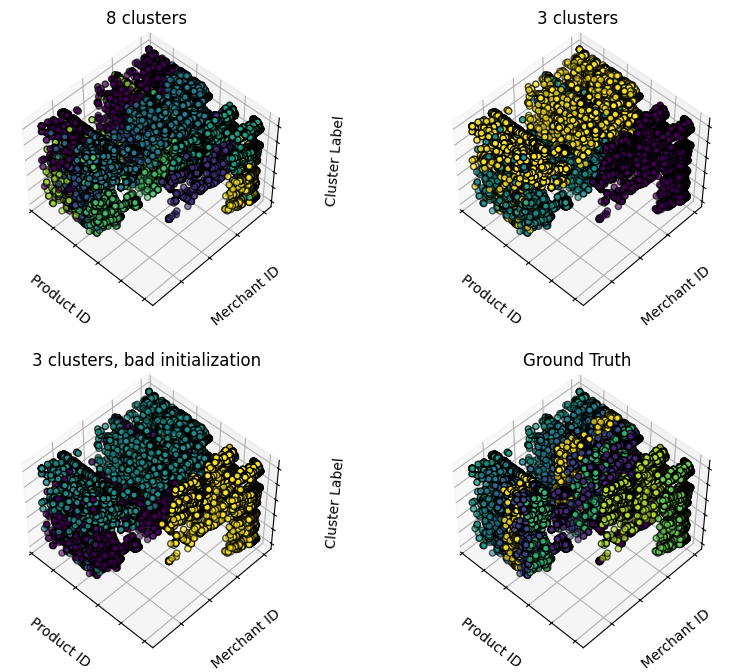

In [55]:
estimators = [
    ("k_means_iris_8", KMeans(n_clusters=8)),
    ("k_means_iris_3", KMeans(n_clusters=3)),
    ("k_means_iris_bad_init", KMeans(n_clusters=3, n_init=1, init="random")),
]

fig = plt.figure(figsize=(10, 8))
titles = ["8 clusters", "3 clusters", "3 clusters, bad initialization"]
for idx, ((name, est), title) in enumerate(zip(estimators, titles)):
    ax = fig.add_subplot(2, 2, idx + 1, projection="3d", elev=48, azim=134)
    est.fit(X)
    labels = est.labels_

    ax.scatter(X["Product ID"], X[" Merchant ID"], X[" Cluster Label"], c=labels.astype(float), edgecolor="k")

    ax.xaxis.set_ticklabels([])
    ax.yaxis.set_ticklabels([])
    ax.zaxis.set_ticklabels([])
    ax.set_xlabel("Product ID")
    ax.set_ylabel(" Merchant ID")
    ax.set_zlabel(" Cluster Label")
    ax.set_title(title)

# Plot the ground truth
ax = fig.add_subplot(2, 2, 4, projection="3d", elev=48, azim=134)

for name, label in [(vals[0], 0), (vals[1], 1), (vals[2], 2)]:
    ds = df_new[df_new[" Category Label"]==name]
    ax.text3D(
        ds["Product ID"].mean(),
        ds[" Merchant ID"].mean(),
        ds[" Cluster Label"].mean(),
        name,
        horizontalalignment="center",
        bbox=dict(alpha=0.2, edgecolor="w", facecolor="w"),
    )

ax.scatter(X["Product ID"], X[" Merchant ID"], X[" Cluster Label"], c=y, edgecolor="k")

ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])
ax.set_xlabel("Product ID")
ax.set_ylabel(" Merchant ID")
ax.set_zlabel(" Cluster Label")
ax.set_title("Ground Truth")

plt.subplots_adjust(wspace=0.25, hspace=0.25)
plt.show()

Метрики

In [56]:
from sklearn import metrics
from sklearn.metrics.cluster import adjusted_rand_score


n_clusters = np.arange(2, 21)

In [57]:
best_metric = [0, 10000, 0,[]]

silhouette_score_values = []
adjusted_rand_score_values = []


for n in n_clusters:

    clusterer = KMeans(n_clusters=n, max_iter=10, n_init=10)
    clusterer.fit(X)
    y_pred = clusterer.predict(X)

    score1 = metrics.silhouette_score(X, y_pred)
    silhouette_score_values.append(score1)

    score2 = metrics.adjusted_rand_score(y, y_pred)
    adjusted_rand_score_values.append(score2)


    if score1 < best_metric[1] and score2 > best_metric[2]:
          best_metric[1] = score1
          best_metric[2] = score2
          best_metric[3] = clusterer.cluster_centers_
          best_metric[0] = n

In [58]:
best_metric

[np.int64(6),
 np.float64(0.43955354365462335),
 0.3424344935369265,
 array([[4.08501469e+04, 6.66194607e+03, 1.63723784e+02, 4.49651767e+04,
         2.92392325e+03, 2.62206101e+03],
        [7.00988249e+03, 2.43214041e+04, 4.41618672e+01, 2.71056270e+03,
         9.61744241e+03, 2.61300302e+03],
        [2.65254336e+04, 2.41589219e+04, 1.43582366e+02, 4.03563101e+04,
         9.69104486e+03, 2.61835146e+03],
        [1.13472920e+04, 1.04913247e+04, 4.56818497e+01, 4.58269324e+03,
         4.51332287e+03, 2.61399903e+03],
        [4.09419091e+04, 2.29854204e+04, 1.86100166e+02, 4.49867221e+04,
         9.33069136e+03, 2.62204502e+03],
        [2.84621301e+04, 7.30509896e+03, 1.35438011e+02, 4.09835927e+04,
         3.20188153e+03, 2.61894871e+03]])]

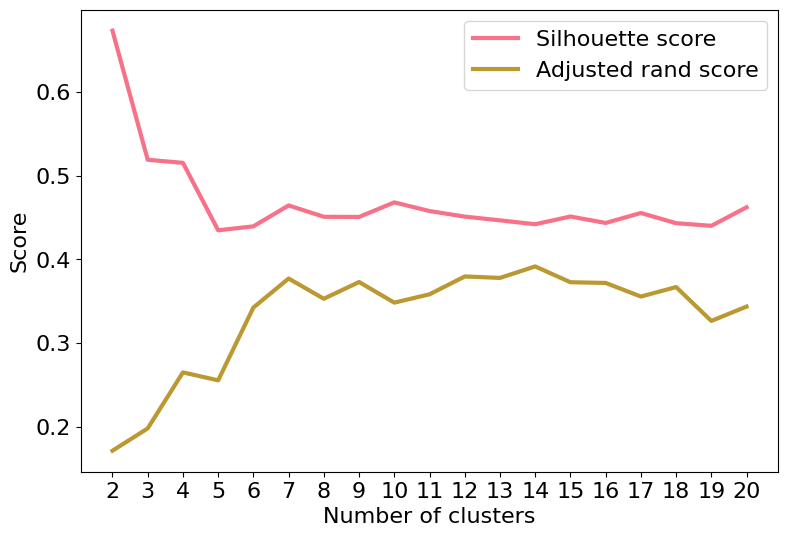

In [59]:
plt.figure(figsize=(9, 6))
plt.plot(n_clusters, silhouette_score_values, linewidth=3, label='Silhouette score')
plt.plot(n_clusters, adjusted_rand_score_values, linewidth=3, label='Adjusted rand score')
plt.xlabel('Number of clusters', size=16)
plt.ylabel('Score', size=16)
plt.xticks(n_clusters, size=16)
plt.yticks(size=16)
plt.legend(loc='best', fontsize=16)

plt.show()

Иерархическая кластеризация

In [60]:
from scipy.cluster.hierarchy import linkage, dendrogram

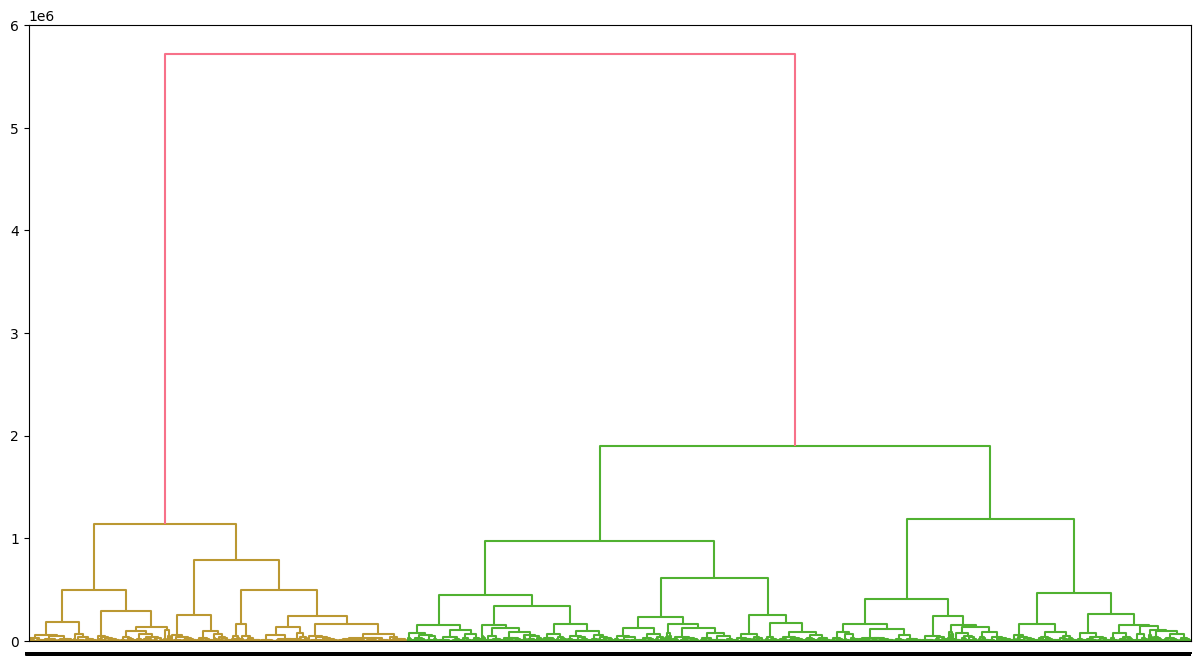

In [61]:
samples = df.values
mergings = linkage(samples, method='ward')

plt.figure(figsize=(15, 8))
dendrogram(mergings,
           labels=list(y),
           leaf_rotation=90,
           leaf_font_size=5,
           )

plt.show()

Оценка алгоритма

In [62]:
n_clusters = len(np.unique(labels))

if n_clusters > 1:
    sc = metrics.silhouette_score(X, labels)
    print("Silhouette Coefficient: %0.2f" % sc)
else:
    print("Silhouette Coefficient: cannot be computed (only 1 cluster found)")

ari = metrics.adjusted_rand_score(y, labels)
print("Adjusted Rand Index: %0.2f" % ari)

Silhouette Coefficient: 0.52
Adjusted Rand Index: 0.20
